In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier  # MLP Model kütüphanesi eklendi
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import shap


C:\Users\omrcl\Desktop\rain-prediction-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the updated dataset with new features (Temp_Range, Humidity_Temp_Interaction)
df = pd.read_csv("../data/processed/weather_final.csv")
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Train-Test Split (80% Train, 20% Test) - Stratify balances the imbalanced target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Data Successfully Loaded with New Features ---")
print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")


--- Data Successfully Loaded with New Features ---
Training set features shape: (112629, 116)
Testing set features shape: (28158, 116)


In [3]:
# 1. Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# 2. Decision Tree (Depth limited to 10 to analyze and prevent overfitting)
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, lr_preds))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_preds))


Training Logistic Regression...
Training Decision Tree...

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     21918
           1       0.74      0.53      0.62      6240

    accuracy                           0.85     28158
   macro avg       0.81      0.74      0.76     28158
weighted avg       0.85      0.85      0.85     28158


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     21918
           1       0.70      0.50      0.58      6240

    accuracy                           0.84     28158
   macro avg       0.78      0.72      0.74     28158
weighted avg       0.83      0.84      0.83     28158



In [4]:
print("Running GridSearchCV for Random Forest Optimization...")
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Parameter grid to satisfy Objective 4 without freezing the system
param_grid = {
    'max_depth': [10, 15],
    'n_estimators': [50, 100]
}

# 3-Fold Cross-Validation targeting F1-score for imbalanced target handling
rf_grid = GridSearchCV(rf_base, param_grid, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"\nBest Hyperparameters Found: {rf_grid.best_params_}")

# Best tuned Random Forest model
rf_model = rf_grid.best_estimator_
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("\n--- Tuned Random Forest Classification Report ---")
print(classification_report(y_test, rf_preds))
print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")


Running GridSearchCV for Random Forest Optimization...

Best Hyperparameters Found: {'max_depth': 15, 'n_estimators': 50}

--- Tuned Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     21918
           1       0.77      0.49      0.60      6240

    accuracy                           0.85     28158
   macro avg       0.82      0.72      0.75     28158
weighted avg       0.85      0.85      0.84     28158

Random Forest ROC-AUC Score: 0.8820


In [5]:
# --- YENİ EKLENEN BÖLÜM: MLP (Neural Network) Hyperparameter Optimization ---
print("Running GridSearchCV for MLP (Neural Network) Optimization...")
mlp_base = MLPClassifier(max_iter=500, random_state=42)

# Sistemi yormayacak dengeli hiperparametre havuzu
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.05]
}

# 3-Fold Cross-Validation (F1-score hedefli)
mlp_grid = GridSearchCV(mlp_base, mlp_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
mlp_grid.fit(X_train, y_train)

print(f"\nBest MLP Hyperparameters Found: {mlp_grid.best_params_}")

# En iyi optimize edilmiş MLP modeli
mlp_model = mlp_grid.best_estimator_
mlp_preds = mlp_model.predict(X_test)
mlp_probs = mlp_model.predict_proba(X_test)[:, 1]

print("\n--- Tuned MLP Classification Report ---")
print(classification_report(y_test, mlp_preds))
print(f"MLP ROC-AUC Score: {roc_auc_score(y_test, mlp_probs):.4f}")


Running GridSearchCV for MLP (Neural Network) Optimization...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best MLP Hyperparameters Found: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'solver': 'adam'}

--- Tuned MLP Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     21918
           1       0.68      0.64      0.66      6240

    accuracy                           0.85     28158
   macro avg       0.79      0.78      0.78     28158
weighted avg       0.85      0.85      0.85     28158

MLP ROC-AUC Score: 0.8880


In [6]:
print("Training Optimized XGBoost Classifier...")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, xgb_preds))
print(f"XGBoost ROC-AUC Score: {roc_auc_score(y_test, xgb_probs):.4f}")


Training Optimized XGBoost Classifier...

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     21918
           1       0.75      0.55      0.64      6240

    accuracy                           0.86     28158
   macro avg       0.82      0.75      0.77     28158
weighted avg       0.85      0.86      0.85     28158

XGBoost ROC-AUC Score: 0.8910


In [7]:
print("--- Overfitting Check ---")
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)
print(f"XGBoost Train Score: {train_score:.4f}")
print(f"XGBoost Test Score: {test_score:.4f}")
print(f"Fark: {train_score - test_score:.4f}")
if train_score - test_score > 0.05:
    print("⚠️ Uyarı: Olası overfitting var!")
else:
    print("✅ Overfitting yok, model dengeli.")


--- Overfitting Check ---
XGBoost Train Score: 0.8721
XGBoost Test Score: 0.8602
Fark: 0.0119
✅ Overfitting yok, model dengeli.


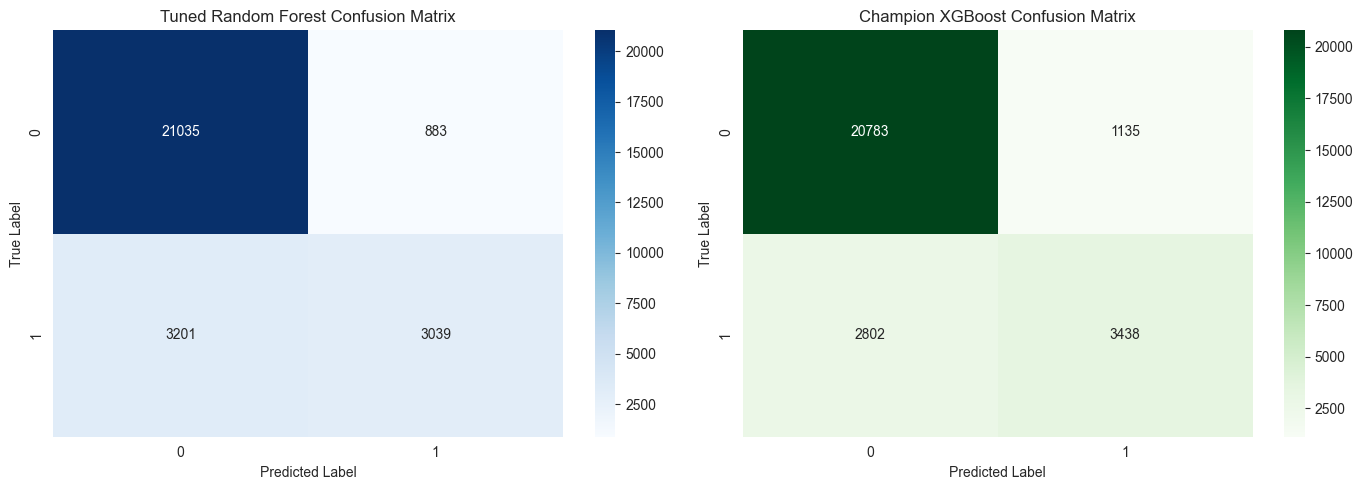

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Tuned Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# XGBoost Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Champion XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


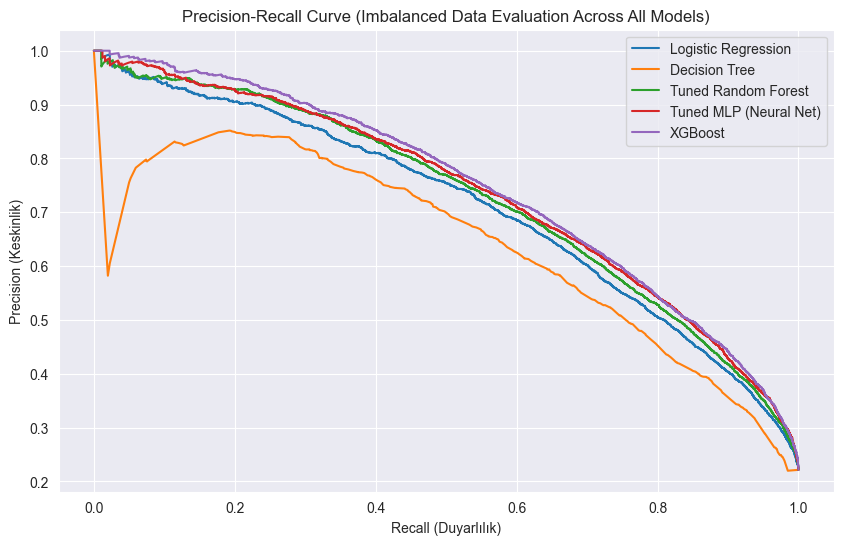

In [9]:
plt.figure(figsize=(10, 6))

# MLP Modeli grafiğe eklendi
models_dict = {
    'Logistic Regression': lr_probs,
    'Decision Tree': dt_probs,
    'Tuned Random Forest': rf_probs,
    'Tuned MLP (Neural Net)': mlp_probs,
    'XGBoost': xgb_probs
}

for model_name, probs in models_dict.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=f"{model_name}")

plt.xlabel('Recall (Duyarlılık)')
plt.ylabel('Precision (Keskinlik)')
plt.title('Precision-Recall Curve (Imbalanced Data Evaluation Across All Models)')
plt.legend()
plt.grid(True)
plt.show()


Calculating SHAP values for model interpretation...


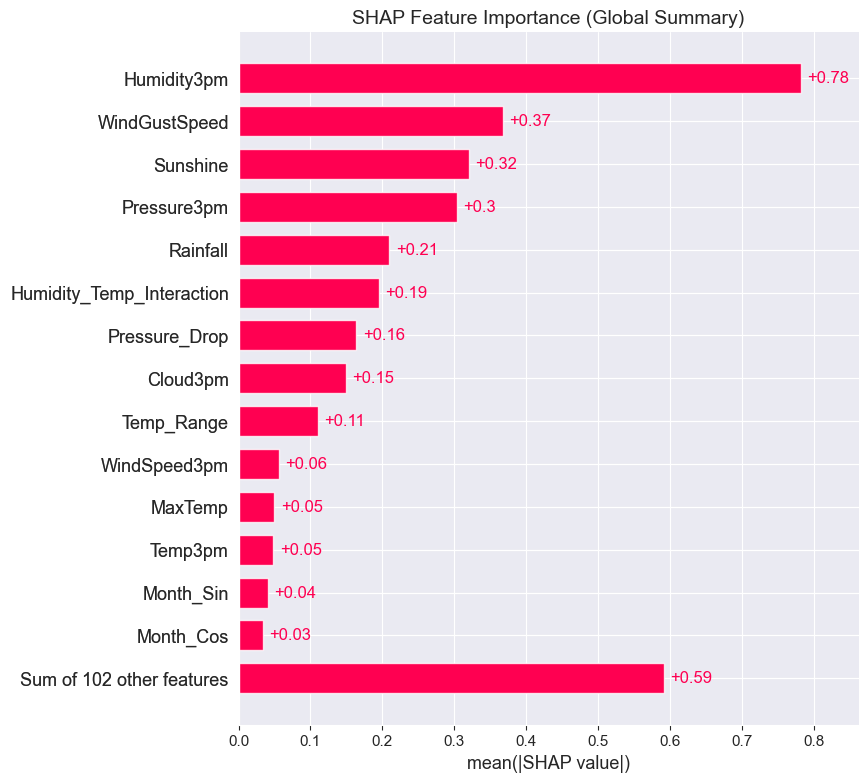

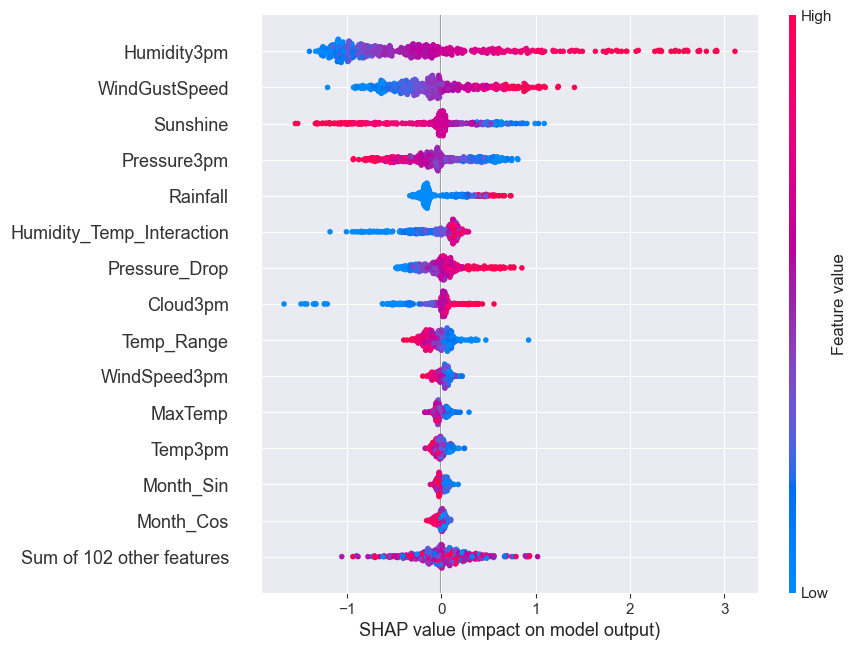

In [10]:
print("Calculating SHAP values for model interpretation...")
explainer = shap.TreeExplainer(xgb_model)

# 500 samples are enough for an accurate and fast global summary
X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer(X_test_sample)

# 1. Global Feature Importance (Bar Plot)
plt.figure(figsize=(10, 5))
plt.title("SHAP Feature Importance (Global Summary)", fontsize=14)
shap.plots.bar(shap_values, max_display=15)
plt.show()

plt.figure(figsize=(10, 5))
shap.plots.beeswarm(shap_values, max_display=15)
plt.show()


In [11]:
import joblib
import os

# 1. Models klasörünü otomatik oluştur (eğer yoksa)
os.makedirs("../models", exist_ok=True)

# 2. Şampiyon XGBoost modelini kaydet
joblib.dump(xgb_model, "../models/xgboost_rain_model.pkl")

# 3. Tuned Random Forest modelini kaydet
joblib.dump(rf_model, "../models/random_forest_tuned.pkl")

# 4. Tuned MLP modelini kaydet
joblib.dump(mlp_model, "../models/mlp_tuned.pkl")

print("--- Modeller Başarıyla '../models/' Klasörüne Kaydedildi! ---")
print("Saved: xgboost_rain_model.pkl")
print("Saved: random_forest_tuned.pkl")
print("Saved: mlp_tuned.pkl")


--- Modeller Başarıyla '../models/' Klasörüne Kaydedildi! ---
Saved: xgboost_rain_model.pkl
Saved: random_forest_tuned.pkl
Saved: mlp_tuned.pkl


--- Model Reliability (Probability Calibration) Test ---


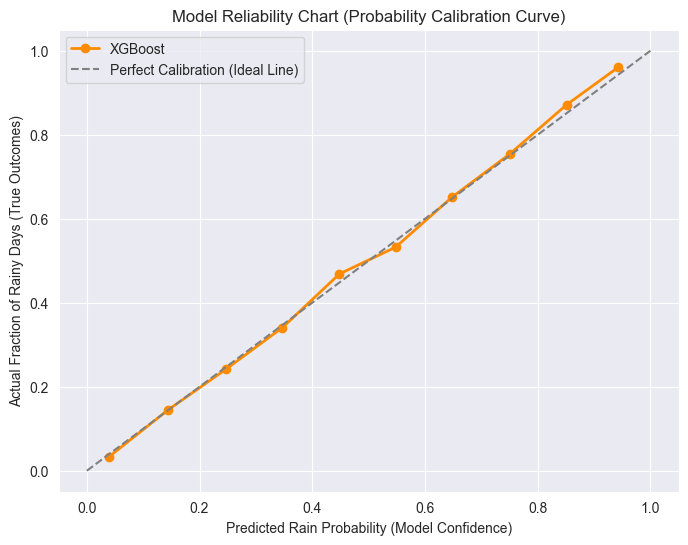

In [12]:
from sklearn.calibration import calibration_curve

print("--- Model Reliability (Probability Calibration) Test ---")

# 1. Compute true vs. predicted probabilities using 10 bins
prob_true, prob_pred = calibration_curve(y_test, xgb_probs, n_bins=10)

# 2. Plot the Calibration Curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='darkorange', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration (Ideal Line)')

plt.xlabel('Predicted Rain Probability (Model Confidence)')
plt.ylabel('Actual Fraction of Rainy Days (True Outcomes)')
plt.title('Model Reliability Chart (Probability Calibration Curve)')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
import os

print("--- Deep Error Analysis Using Original-Scale Data ---")

# Cleaned but NOT scaled/encoded dataset
processed_raw_path = "../data/processed/weather_processed.csv"

if os.path.exists(processed_raw_path):
    df_processed = pd.read_csv(processed_raw_path)

    # Keep only the test set observations
    processed_test = df_processed.loc[X_test.index].copy()
    processed_test['Actual'] = y_test.values
    processed_test['Predicted'] = xgb_preds

    # Error groups
    fps = processed_test[
        (processed_test['Actual'] == 0) &
        (processed_test['Predicted'] == 1)
    ]

    fns = processed_test[
        (processed_test['Actual'] == 1) &
        (processed_test['Predicted'] == 0)
    ]

    print(f"Total Test Samples: {len(X_test)}")
    print(f"False Positives (False Rain Alerts): {len(fps)}")
    print(f"False Negatives (Missed Rainy Days): {len(fns)}")

    print("\n=== Meteorological Characteristics Comparison ===")

    print(f"Average Humidity3pm (Entire Test Set): {processed_test['Humidity3pm'].mean():.2f}%")
    print(f"Average Humidity3pm (False Positives): {fps['Humidity3pm'].mean():.2f}%")
    print(f"Average Humidity3pm (False Negatives): {fns['Humidity3pm'].mean():.2f}%")

    print(f"\nAverage Pressure3pm (Entire Test Set): {processed_test['Pressure3pm'].mean():.2f} hPa")
    print(f"Average Pressure3pm (False Positives): {fps['Pressure3pm'].mean():.2f} hPa")
    print(f"Average Pressure3pm (False Negatives): {fns['Pressure3pm'].mean():.2f} hPa")

    print(f"\nAverage Sunshine (Entire Test Set): {processed_test['Sunshine'].mean():.2f} hours")
    print(f"Average Sunshine (False Positives): {fps['Sunshine'].mean():.2f} hours")
    print(f"Average Sunshine (False Negatives): {fns['Sunshine'].mean():.2f} hours")

    print(f"\nAverage WindGustSpeed (Entire Test Set): {processed_test['WindGustSpeed'].mean():.2f} km/h")
    print(f"Average WindGustSpeed (False Positives): {fps['WindGustSpeed'].mean():.2f} km/h")
    print(f"Average WindGustSpeed (False Negatives): {fns['WindGustSpeed'].mean():.2f} km/h")

else:
    print("weather_processed.csv was not found. Please verify the file path.")

--- Deep Error Analysis Using Original-Scale Data ---
Total Test Samples: 28158
False Positives (False Rain Alerts): 1135
False Negatives (Missed Rainy Days): 2802

=== Meteorological Characteristics Comparison ===
Average Humidity3pm (Entire Test Set): 51.55%
Average Humidity3pm (False Positives): 71.96%
Average Humidity3pm (False Negatives): 56.51%

Average Pressure3pm (Entire Test Set): 1015.28 hPa
Average Pressure3pm (False Positives): 1011.71 hPa
Average Pressure3pm (False Negatives): 1014.47 hPa

Average Sunshine (Entire Test Set): 8.04 hours
Average Sunshine (False Positives): 5.83 hours
Average Sunshine (False Negatives): 7.46 hours

Average WindGustSpeed (Entire Test Set): 39.68 km/h
Average WindGustSpeed (False Positives): 47.06 km/h
Average WindGustSpeed (False Negatives): 40.83 km/h
